# 6. Univariate Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I studied each required categorical and numerical variable independently using frequency tables, descriptive statistics, distributions, and boxplots.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


## Categorical Variables

In [2]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()


--- GENRE ---


,count
genre,
Animation,10028
Drama,6142
Action & Adventure,4705
Reality,4005
Comedy,3067
Talk,2074
Crime,926
Kids,632
Sci-Fi & Fantasy,574


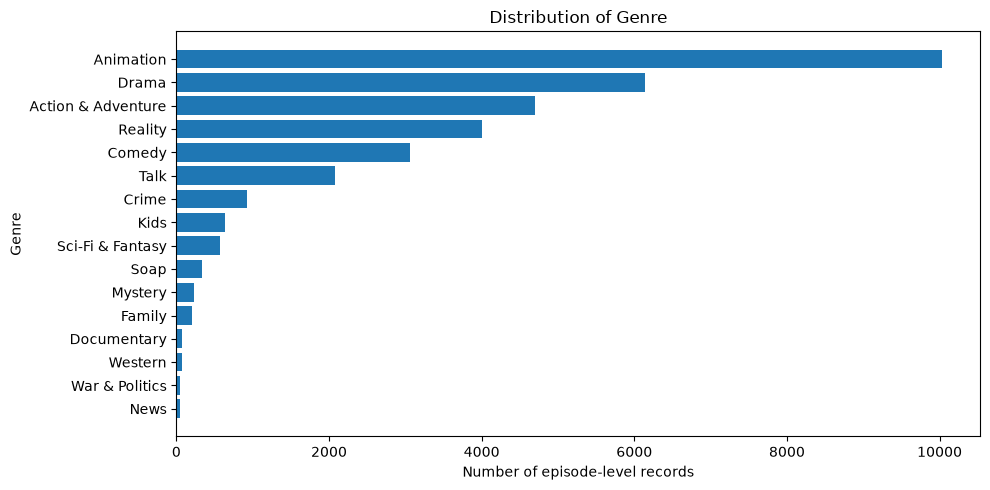


--- PLATFORM ---


,count
platform,
Netflix,12270
Hulu,7967
Prime Video,2693
Disney+,2467
Kocowa Amazon Channel,2245
OnDemandKorea,1582
Rakuten Viki,911
Peacock Premium,686
fuboTV,550


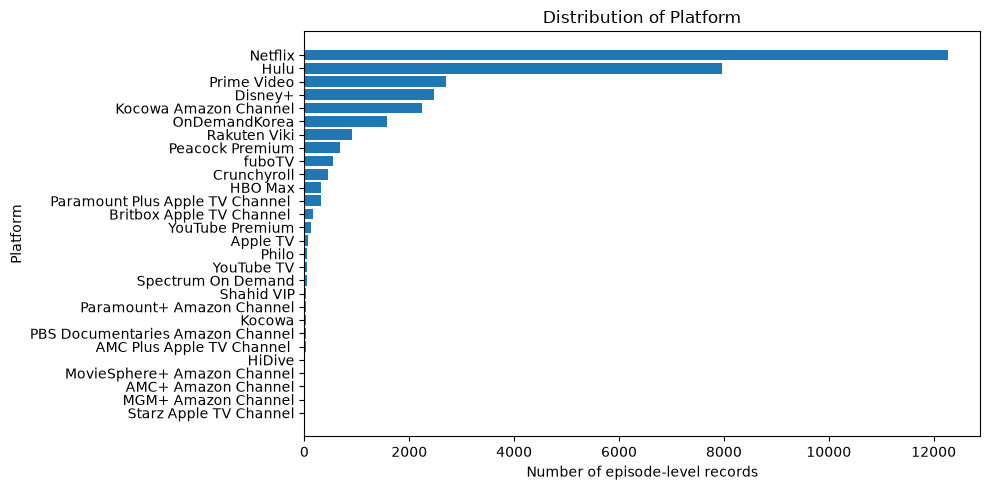


--- ATTENTION_REQUIRED ---


,count
attention_required,
high,16878
medium,16293


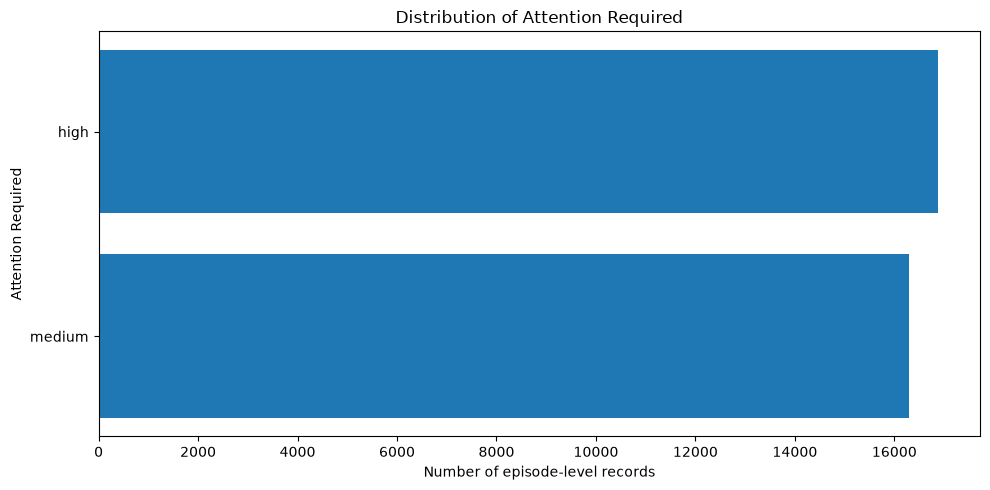


--- RETENTION_RISK ---


,count
retention_risk,
medium,27402
high,4804
low,965


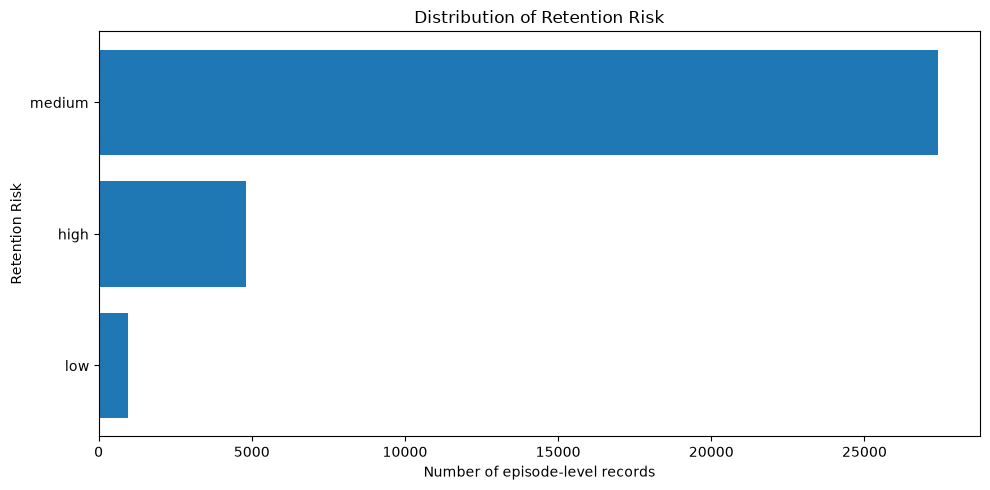

In [3]:
# PROCESS: Count each category, display the frequency table, and visualize the counts.
categorical_vars = ["genre", "platform", "attention_required", "retention_risk"]

for col in categorical_vars:
    print(f"\n--- {col.upper()} ---")

    # Count all observed values, including missing values if they ever appear.
    counts_with_missing = df[col].value_counts(dropna=False)
    display(counts_with_missing.to_frame("count"))

    # For plotting, use non-missing category counts and sort them for readability.
    plot_counts = df[col].dropna().value_counts().sort_values(ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(plot_counts.index.astype(str), plot_counts.values)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel("Number of episode-level records")
    plt.ylabel(col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()
    plt.close()

## Numerical Distributions

,count,mean,std,min,25%,50%,75%,max
episode_duration_min,33171.0,37.660667,22.899741,1.00,24.0,33.000,49.000,1225.000
avg_watch_percentage,33171.0,56.805764,12.577000,13.00,48.0,57.000,66.000,100.000
pause_count,33171.0,3.102921,1.866938,0.00,2.0,3.000,4.000,10.000
rewind_count,33171.0,2.003497,1.548391,0.00,1.0,2.000,3.000,8.000
hook_strength,33171.0,5.525158,1.730098,3.00,4.0,6.000,7.000,10.000
pacing_score,33171.0,5.397908,1.230418,3.00,4.0,5.000,6.000,8.000
cognitive_load,33171.0,6.196015,1.322146,4.00,5.0,7.000,7.000,9.000
drop_off_probability,33171.0,0.478433,0.107382,0.12,0.4,0.471,0.553,0.831


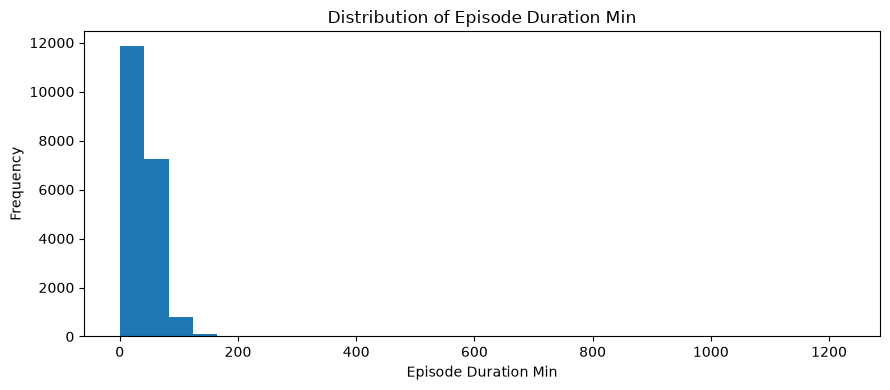

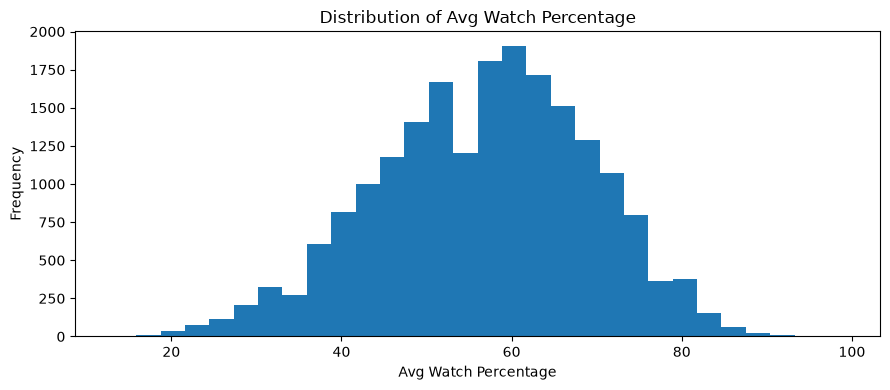

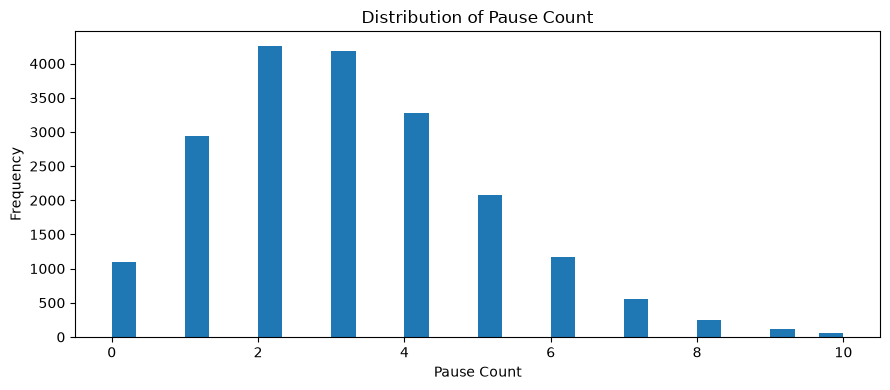

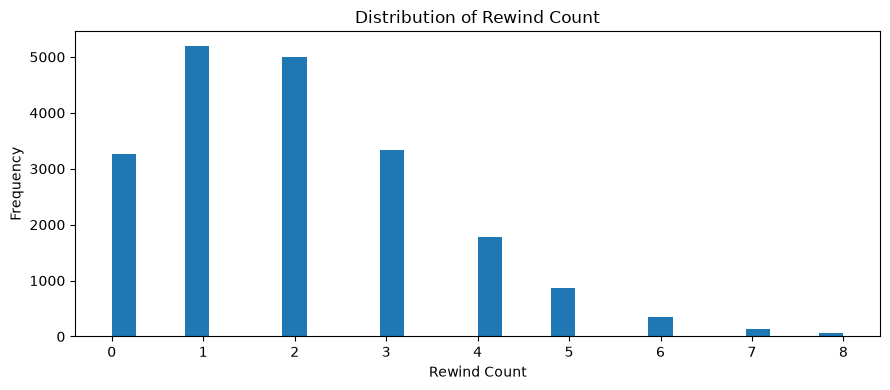

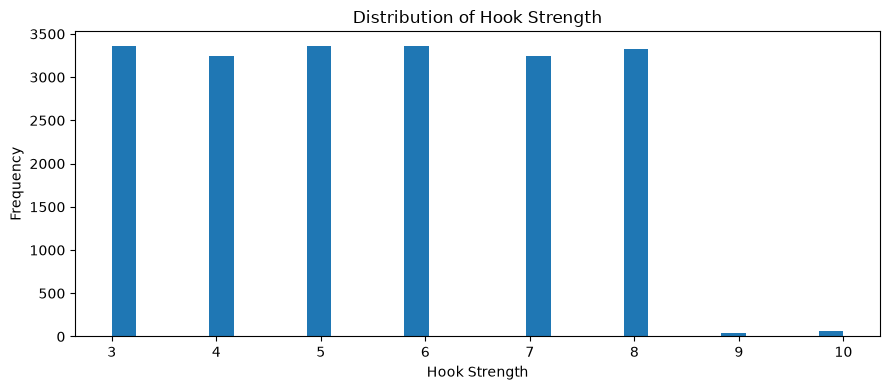

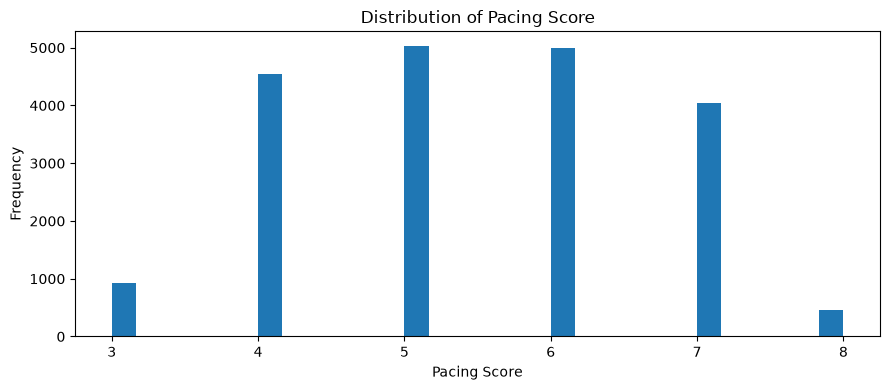

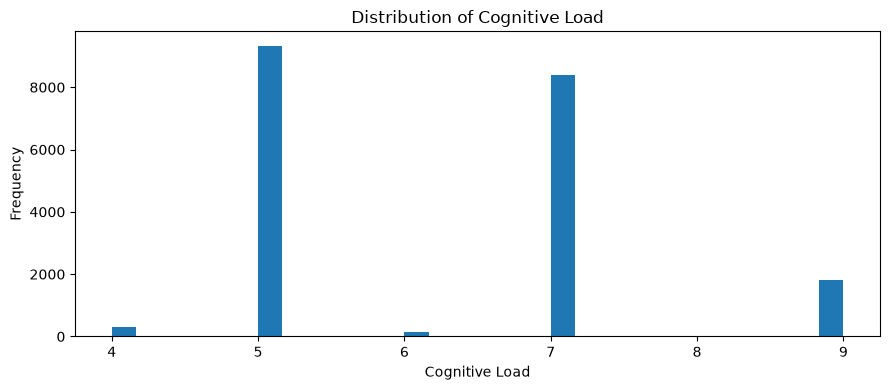

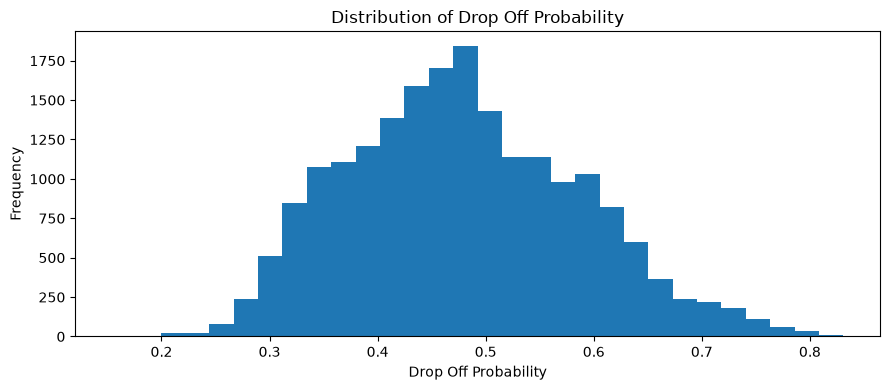

In [4]:
# PROCESS: Summarize and visualize each required numerical variable separately.
numerical_vars = [
    "episode_duration_min",
    "avg_watch_percentage",
    "pause_count",
    "rewind_count",
    "hook_strength",
    "pacing_score",
    "cognitive_load",
    "drop_off_probability",
]

# Descriptive statistics show center, spread, minimum, maximum, and quartiles.
display(df[numerical_vars].describe().T)

for col in numerical_vars:
    # Remove missing values only for the current plot.
    # The audit found no missing values, but dropna() makes the code robust.
    values = df[col].dropna()
    if len(values) > 20000:
        values = values.sample(20000, random_state=42)

    plt.figure(figsize=(9, 4))
    plt.hist(values, bins=30)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    plt.close()

## Outlier-Oriented Boxplots

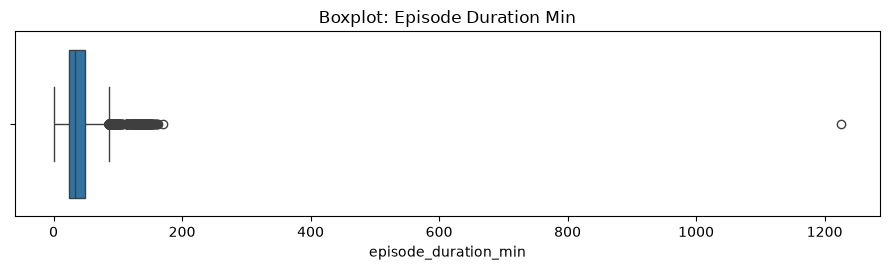

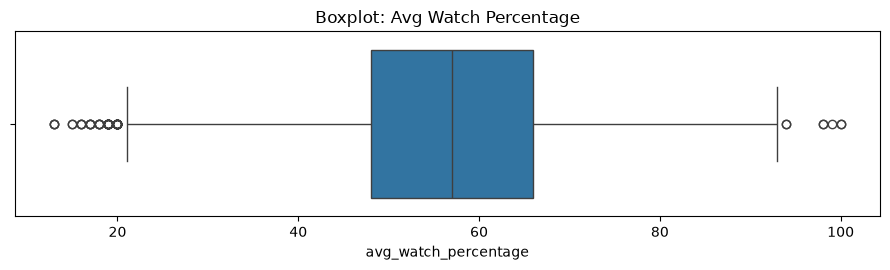

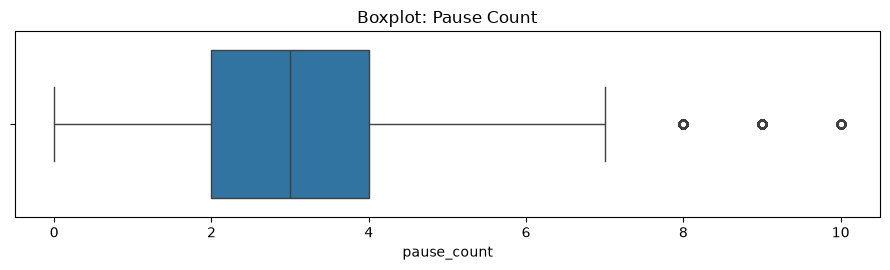

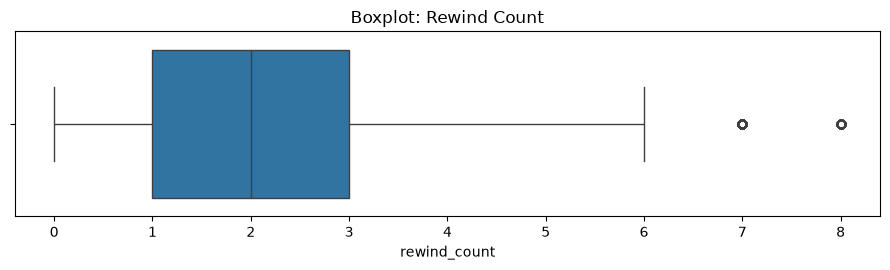

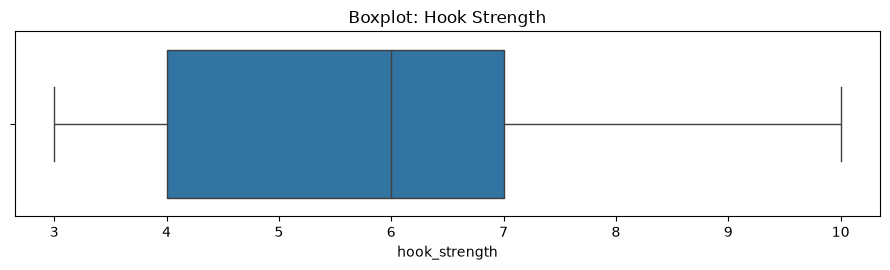

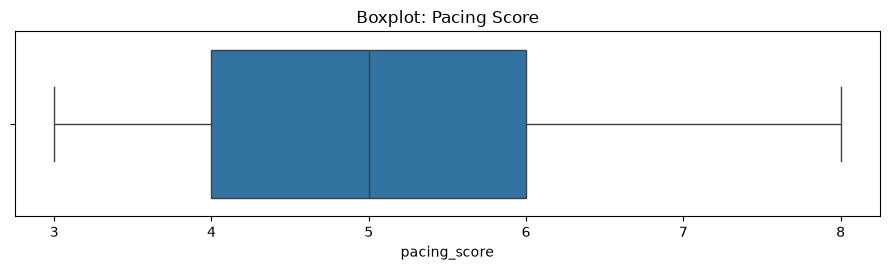

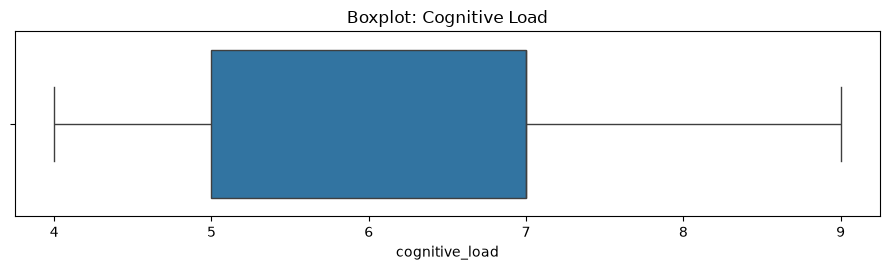

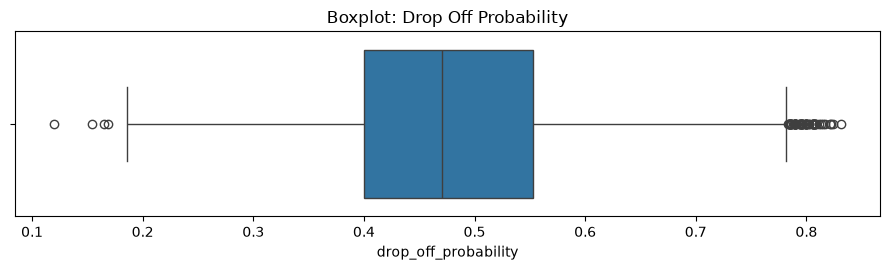

In [5]:
# PROCESS: Visualize the summarized relationship so patterns are easier to interpret.
for col in numerical_vars:
    plt.figure(figsize=(9, 2.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()
    plt.close()

### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Mean, Median, Standard Deviation, and Sample Size

Means alone can be affected by skew and extreme observations.  
This summary adds medians, standard deviations, and valid observation counts for more defensible interpretation.

In [6]:
robust_numeric_summary = df[numerical_vars].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

display(robust_numeric_summary.round(3))

,count,mean,median,std,min,max
episode_duration_min,33171.0,37.661,33.000,22.900,1.00,1225.000
avg_watch_percentage,33171.0,56.806,57.000,12.577,13.00,100.000
pause_count,33171.0,3.103,3.000,1.867,0.00,10.000
rewind_count,33171.0,2.003,2.000,1.548,0.00,8.000
hook_strength,33171.0,5.525,6.000,1.730,3.00,10.000
pacing_score,33171.0,5.398,5.000,1.230,3.00,8.000
cognitive_load,33171.0,6.196,7.000,1.322,4.00,9.000
drop_off_probability,33171.0,0.478,0.471,0.107,0.12,0.831


In [7]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
